In [1]:
!pip install timm seaborn


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 4.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typer
    Found existing installation: typer 0.12.5
    Uninstalling typer-0.12.5:
      Successfully uninstalled typer-0.12.5

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os
import random
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [3]:
DATASET_ROOT = "./allplants/"  # CHANGE THIS

DEVICE = "cuda:4" if torch.cuda.is_available() else "cpu"

NUM_CLASSES = 23
BATCH_SIZE = 64
EPOCHS = 120
LR = 5e-4
WEIGHT_DECAY = 0.05
NUM_FOLDS = 5
PATIENCE = 15  # Early stopping
GRAD_CLIP = 1.0

SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using device:", DEVICE)


Using device: cuda:4


In [4]:
class_names = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

assert len(class_names) == NUM_CLASSES, "Class count mismatch!"

class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    cls_folder = os.path.join(DATASET_ROOT, cls)
    
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
        for img_path in glob(os.path.join(cls_folder, ext)):
            image_paths.append(img_path)
            labels.append(class_to_idx[cls])

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()


Total images: 17539


,image_path,label
0,./allplants/appleLeaf/c9ae1b9019698f2f.jpg,0
1,./allplants/appleLeaf/000711.jpg,0
2,./allplants/appleLeaf/000435.jpg,0
3,./allplants/appleLeaf/000505.jpg,0
4,./allplants/appleLeaf/b04827b3e460ff2d.jpg,0


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train+Val:", len(train_df))
print("Test:", len(test_df))


Train+Val: 14908
Test: 2631


In [6]:
class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [7]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [8]:
def build_model():
    model = timm.create_model(
        "convnext_small",
        pretrained=True,
        num_classes=NUM_CLASSES
    )
    return model.to(DEVICE)


In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")

    return running_loss/len(loader), acc, f1, precision, recall


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")

    return running_loss/len(loader), acc, f1, precision, recall


In [ ]:
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["label"])):
    
    print(f"\n========== FOLD {fold+1} ==========")
    
    fold_train_df = train_df.iloc[train_idx]
    fold_val_df = train_df.iloc[val_idx]

    train_dataset = PlantDataset(fold_train_df, train_transform)
    val_dataset = PlantDataset(fold_val_df, val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=4,
                              pin_memory=True, persistent_workers=True)

    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=4,
                            pin_memory=True, persistent_workers=True)

    model = build_model()

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        train_loss, train_acc, train_f1, train_prec, train_rec = train_one_epoch(
            model, train_loader, criterion, optimizer)

        val_loss, val_acc, val_f1, val_prec, val_rec = validate(
            model, val_loader, criterion)

        scheduler.step()

        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0

            model_path = os.path.join(SAVE_DIR, f"best_model_fold_{fold+1}.pth")

            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "val_acc": val_acc
            }, model_path)

            print("✅ Best model saved.")

        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("⛔ Early stopping triggered.")
            break

    fold_results.append(best_val_acc)

print("\nCross Validation Results:")
print(f"Mean Accuracy: {np.mean(fold_results):.4f}")
print(f"Std Accuracy: {np.std(fold_results):.4f}")

best_fold_index = np.argmax(fold_results) + 1
print("Best Fold:", best_fold_index)



========== FOLD 1 ==========

Epoch 1/120


100%|█████████████████████████████████████████████████████████████████████████████████| 187/187 [01:32<00:00,  2.02it/s]
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train Loss: 2.3239 | Acc: 0.3566 | F1: 0.2926
Val   Loss: 1.6682 | Acc: 0.6009 | F1: 0.5116
✅ Best model saved.

Epoch 2/120


100%|█████████████████████████████████████████████████████████████████████████████████| 187/187 [01:34<00:00,  1.98it/s]


Train Loss: 1.4749 | Acc: 0.6674 | F1: 0.6028
Val   Loss: 1.2179 | Acc: 0.7864 | F1: 0.7373
✅ Best model saved.

Epoch 3/120


...

100%|█████████████████████████████████████████████████████████████████████████████████| 187/187 [01:23<00:00,  2.25it/s]


Train Loss: 0.6256 | Acc: 0.9954 | F1: 0.9947
Val   Loss: 0.6574 | Acc: 0.9832 | F1: 0.9804

Epoch 59/120


100%|█████████████████████████████████████████████████████████████████████████████████| 187/187 [01:20<00:00,  2.33it/s]


Train Loss: 0.6275 | Acc: 0.9943 | F1: 0.9935
Val   Loss: 0.6672 | Acc: 0.9802 | F1: 0.9749

Epoch 60/120


 32%|██████████████████████████▎                                                       | 60/187 [00:26<00:44,  2.88it/s]

In [10]:
best_model = build_model()

best_model_path = os.path.join(SAVE_DIR, f"best_model_fold_{best_fold_index}.pth")

checkpoint = torch.load(best_model_path)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

test_dataset = PlantDataset(test_df, val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Macro F1:", f1_score(all_labels, all_preds, average="macro"))
print("Precision:", precision_score(all_labels, all_preds, average="macro"))
print("Recall:", recall_score(all_labels, all_preds, average="macro"))

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


NameError: name 'best_fold_index' is not defined

In [11]:
import os
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm


In [12]:
DATASET_ROOT = "./allplants/"   # SAME AS TRAINING
SAVE_DIR = "./saved_models"              # SAME AS TRAINING

DEVICE = "cuda:5" if torch.cuda.is_available() else "cpu"

NUM_CLASSES = 23
BATCH_SIZE = 64

print("Using device:", DEVICE)


Using device: cuda:5


In [13]:
class_names = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

assert len(class_names) == NUM_CLASSES, "Class count mismatch!"

class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}


In [14]:
image_paths = []
labels = []

for cls in class_names:
    cls_folder = os.path.join(DATASET_ROOT, cls)
    
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
        for img_path in glob(os.path.join(cls_folder, ext)):
            image_paths.append(img_path)
            labels.append(class_to_idx[cls])

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))


Total images: 17539


In [15]:
from sklearn.model_selection import train_test_split

_, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)

test_df = test_df.reset_index(drop=True)

print("Test size:", len(test_df))


Test size: 2631


In [16]:
class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [17]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [23]:
test_dataset = PlantDataset(test_df, val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Test loader ready.")


Test loader ready.


In [18]:
def build_model():
    model = timm.create_model(
        "convnext_small",
        pretrained=False,  # Important: Do NOT reload pretrained weights
        num_classes=NUM_CLASSES
    )
    return model.to(DEVICE)

best_model = build_model()


In [19]:
best_model_path = os.path.join(
    SAVE_DIR,
    f"best_model_fold_{best_fold_index}.pth"
)

checkpoint = torch.load(best_model_path, map_location=DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Model loaded from:", best_model_path)


NameError: name 'best_fold_index' is not defined

In [20]:
import glob

# Get all fold checkpoint files
model_files = glob.glob(os.path.join(SAVE_DIR, "best_model_fold_*.pth"))

assert len(model_files) > 0, "No saved models found!"

best_acc = -1
best_model_path = None

for path in model_files:
    checkpoint = torch.load(path, map_location=DEVICE)
    val_acc = checkpoint.get("val_acc", 0)
    
    print(f"{os.path.basename(path)} → Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_path = path

print("\nBest Model Selected:", best_model_path)
print("Best Validation Accuracy:", best_acc)


/tmp/ipykernel_293/1034085264.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=DEVICE)


best_model_fold_2.pth → Val Acc: 0.9916
best_model_fold_3.pth → Val Acc: 0.9876
best_model_fold_5.pth → Val Acc: 0.9836
best_model_fold_1.pth → Val Acc: 0.9906
best_model_fold_4.pth → Val Acc: 0.9893

Best Model Selected: ./saved_models/best_model_fold_2.pth
Best Validation Accuracy: 0.9916163648558015


In [21]:
best_model = build_model()

checkpoint = torch.load(best_model_path, map_location=DEVICE)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("Model successfully loaded.")


/tmp/ipykernel_293/1383819112.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=DEVICE)


Model successfully loaded.


In [24]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Macro F1:", f1_score(all_labels, all_preds, average="macro"))
print("Precision:", precision_score(all_labels, all_preds, average="macro"))
print("Recall:", recall_score(all_labels, all_preds, average="macro"))

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))


Test Accuracy: 0.9897377423033067
Macro F1: 0.9873237856216727
Precision: 0.9889848117727228
Recall: 0.9858899214787484

Classification Report:

                  precision    recall  f1-score   support

       appleLeaf       0.99      0.99      0.99       135
      bananaStem       1.00      1.00      1.00       150
   blackgramLeaf       1.00      0.99      0.99       150
     brinjalLeaf       1.00      1.00      1.00        98
     cassavaLeaf       0.98      0.99      0.99       150
     cauliflower       0.96      0.93      0.95        57
      cherryLeaf       1.00      0.99      1.00       150
    chicpeaPlant       1.00      1.00      1.00       150
      cottonLeaf       0.97      1.00      0.98        97
    cucumberLeaf       0.97      1.00      0.98       150
        juteLeaf       0.99      0.99      0.99        75
      mangoFruit       1.00      0.96      0.98        55
       mangoLeaf       0.99      0.99      0.99       150
pomegranateFruit       1.00      1.00     

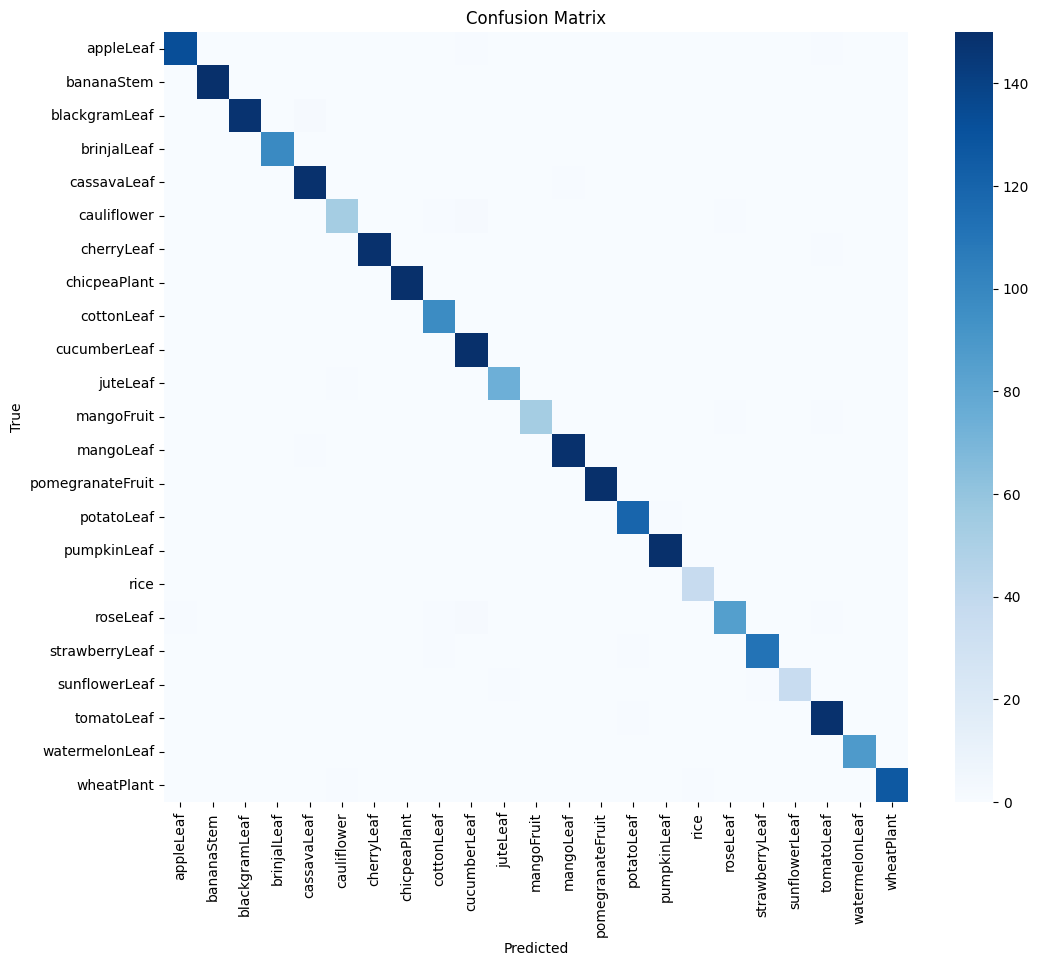

In [25]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [26]:
import os

SAVE_DIR = "./saved_models"   # same directory
os.makedirs(SAVE_DIR, exist_ok=True)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")

plt.savefig(cm_path, dpi=300)   # High resolution
plt.close()

print("Confusion matrix saved to:", cm_path)


Confusion matrix saved to: ./saved_models/confusion_matrix.png


In [27]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()

cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_normalized.png")

plt.savefig(cm_norm_path, dpi=300)
plt.close()

print("Normalized confusion matrix saved to:", cm_norm_path)


Normalized confusion matrix saved to: ./saved_models/confusion_matrix_normalized.png
